# Iron Condor simulation

This notebook implements the [iron condor](https://www.investopedia.com/articles/optioninvestor/06/ironcondor.asp) strategy. It was created by OpenAI's [Codex](https://openai.com/codex/) using `optionlab-black-scholes` and `optionlab-strategy` skills with the following prompt:

> Let's simulate an Iron Condor. The stock price is US$ 100. We buy 100 put options with a strike price of US\\$ 90 and sell 100 put options with a
> strike price of US\\$ 95. We sell 100 call options with a strike price of US\\$ 105 and buy 100 call options with a strike price of US\\$ 110. The
> volatility is 0.2, the risk-free interest rate is 0.05, and all options expire in 20 days. Option prices must be calculated using the Black-Scholes
> model via the `optionlab-black-scholes` skill. The simulation must use the `optionlab-strategy` skill and display both the simulation result and the
> strategy chart. Implement the necessary code in a Jupyter notebook named `iron-condor.ipynb`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from optionlab.black_scholes import get_bs_info
from optionlab import run_strategy, plot_pl

# Market assumptions
stock_price = 100.0
volatility = 0.20
interest_rate = 0.05
days_to_expiration = 20
days_in_year = 365
years_to_maturity = days_to_expiration / days_in_year
quantity = 100


In [2]:
# Calculate every option premium with OptionLab's Black–Scholes API.
# get_bs_info returns call and put values for a given strike.
strikes = [90.0, 95.0, 105.0, 110.0]
bs_by_strike = {
    strike: get_bs_info(
        s=stock_price, x=strike, r=interest_rate, vol=volatility,
        years_to_maturity=years_to_maturity
    )
    for strike in strikes
}

legs = [
    {"type": "put",  "strike": 90.0,  "premium": float(bs_by_strike[90.0].put_price),   "n": quantity, "action": "buy"},
    {"type": "put",  "strike": 95.0,  "premium": float(bs_by_strike[95.0].put_price),   "n": quantity, "action": "sell"},
    {"type": "call", "strike": 105.0, "premium": float(bs_by_strike[105.0].call_price), "n": quantity, "action": "sell"},
    {"type": "call", "strike": 110.0, "premium": float(bs_by_strike[110.0].call_price), "n": quantity, "action": "buy"},
]

premium_table = pd.DataFrame([
    {"leg": "Long put",   "strike": 90.0,  "Black-Scholes premium": legs[0]["premium"]},
    {"leg": "Short put",  "strike": 95.0,  "Black-Scholes premium": legs[1]["premium"]},
    {"leg": "Short call", "strike": 105.0, "Black-Scholes premium": legs[2]["premium"]},
    {"leg": "Long call",  "strike": 110.0, "Black-Scholes premium": legs[3]["premium"]},
])
display(premium_table.style.format({"Black-Scholes premium": "${:,.4f}"}))


,leg,strike,Black-Scholes premium
0,Long put,90.000000,$0.0158
1,Short put,95.000000,$0.2806
2,Short call,105.000000,$0.4117
3,Long call,110.000000,$0.0442


In [3]:
# Simulate the complete four-leg strategy at expiration.
# The displayed price range is only for the chart; PoP uses the full Black–Scholes distribution.
iron_condor_inputs = {
    "stock_price": stock_price,
    "volatility": volatility,
    "interest_rate": interest_rate,
    "min_stock": 75.0,
    "max_stock": 125.0,
    "price_step": 0.10,
    "days_to_target_date": days_to_expiration,
    "discard_nonbusiness_days": False,
    "calculations": ["pop", "expectation"],
    "strategy": legs,
}

result = run_strategy(iron_condor_inputs)

simulation_result = pd.DataFrame({
    "Metric": [
        "Net credit received", "Probability of profit",
        "Expected profit if profitable", "Expected loss if unprofitable",
        "Minimum return in displayed domain", "Maximum return in displayed domain",
    ],
    "Value": [
        f"${result.strategy_cost:,.2f}",
        f"{result.probability_of_profit:.2%}",
        f"${result.expected_profit_if_profitable:,.2f}",
        f"${result.expected_loss_if_unprofitable:,.2f}",
        f"${result.minimum_return_in_the_domain:,.2f}",
        f"${result.maximum_return_in_the_domain:,.2f}",
    ],
})
display(simulation_result)


,Metric,Value
0,Net credit received,$63.22
1,Probability of profit,77.04%
2,Expected profit if profitable,$60.96
3,Expected loss if unprofitable,$-205.33
4,Minimum return in displayed domain,$-436.78
5,Maximum return in displayed domain,$63.22


Profit/Loss diagram:
--------------------
The vertical green dashed line corresponds to the position of the stock's spot price. The right and left arrow markers indicate the strike prices of calls and puts, respectively, with blue representing long and red representing short positions.


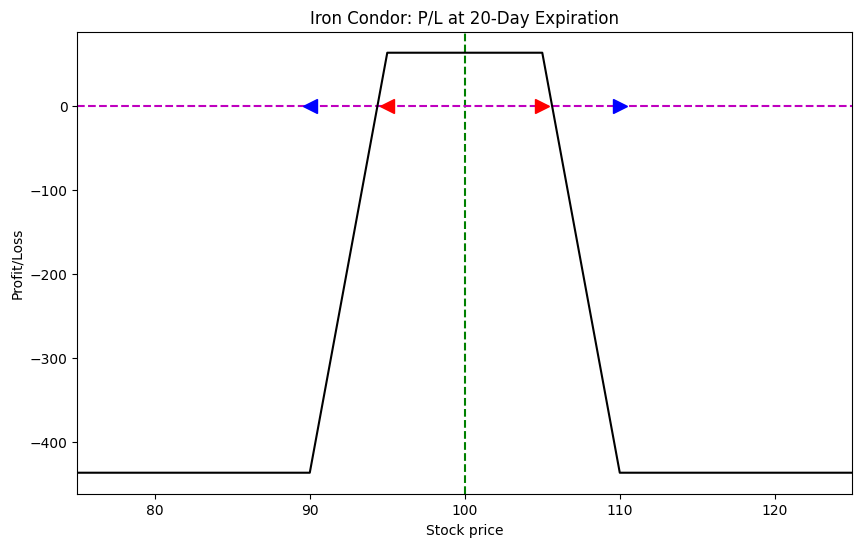

In [4]:
# Strategy P/L chart at expiration
fig = plt.figure(figsize=(10, 6))
plot_pl(result)
plt.title("Iron Condor: P/L at 20-Day Expiration")
plt.show()
